# K‑Means Project
## California Housing Clustering - Grouping houses by Region and income

MSalaverri

Grouping California houses into six clusters based on their latitude, longitude, and median income. Explore unsupervised learning for geographic and socioeconomic segmentation.

**Type of Problem:** Unsupervised clustering followed by supervised classification.

In [40]:
# IMPORT LIBRARIES

# Data manipulation & visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Saving models
import joblib

import warnings
warnings.filterwarnings('ignore')


In [41]:
# LOADING ORIGINAL DATA
data = "https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv"
df = pd.read_csv(data)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Exploratory Data Analysis

In [42]:
#Dataset dimension
rows, column = df.shape
print("DATASET Dimension:")
print(f'{rows} rows and {column} columns')

DATASET Dimension:
20640 rows and 9 columns


In [44]:
# Lets select only Latitude, Longitude, and MedInc
df = df[["Latitude", "Longitude", "MedInc"]]

rows, column = df.shape
print("\nNEW DATASET Dimension (after selecting only Latitude, Longitude, and MedInc):")
print(f'{rows} rows and {column} columns')

df.head()


NEW DATASET Dimension (after selecting only Latitude, Longitude, and MedInc):
20640 rows and 3 columns


,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


In [45]:
# Get information about range index, number of columns and labels, data types, and the number of cells in each column (non-null values)
print("DATASET General Info:")
df.info()

DATASET General Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Latitude   20640 non-null  float64
 1   Longitude  20640 non-null  float64
 2   MedInc     20640 non-null  float64
dtypes: float64(3)
memory usage: 483.9 KB


In [46]:
#List Missing values
all_missing_values = df.isnull().sum()
print("Missing Values per Column:")
all_missing_values.reset_index()

Missing Values per Column:


,index,0
0,Latitude,0
1,Longitude,0
2,MedInc,0


In [47]:
num_of_zeros = (df == 0).sum()
print("Count of Zeros per Column:")
num_of_zeros.sort_values(ascending=False).reset_index()

Count of Zeros per Column:


,index,0
0,Latitude,0
1,Longitude,0
2,MedInc,0


In [48]:
print("\nDESCRIPTIVE BASIC STATISTIC:")
df.describe()


DESCRIPTIVE BASIC STATISTIC:


,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


### Initial Inspection Summary
The dataset contains 20,640 rows and 9 original columns, each row representing a census block group from California in 1990. The original features included demographic and housing variables.

For this project, we'll selected only the three most relevant columns:

- Latitude: geographic coordinate north–south.

- Longitude: geographic coordinate east–west.

- MedInc: median household income in the block group.

The reduced dataset now has 20,640 rows and 3 columns, with all values fully populated and no missing data.

**Comment:** This simplified dataset is clean, numeric, and well‑structured. Latitude and longitude provide geographic positioning, while median income adds socioeconomic context. Together, these features are suitable for clustering houses into regional and income‑based groups using K‑Means.

## Data Prep

### Duplicates

In [49]:
#Looking for Duplicates
duplicates = df.duplicated()
sum_duplicates = duplicates.sum()

# Verifying Duplicates
print(f"Duplicated Rows: {sum_duplicates}")

df = df.drop_duplicates()
rows, column = df.shape
print("\nNEW DATASET Dimension (after removing duplicates):")
print(f'{rows} rows and {column} columns')

Duplicated Rows: 5

NEW DATASET Dimension (after removing duplicates):
20635 rows and 3 columns


## Visualization and Data Analysis

In [50]:
#Show Unique values per column name
n_uniques = df.nunique()
n_uniques.reset_index()

,index,0
0,Latitude,862
1,Longitude,844
2,MedInc,12928


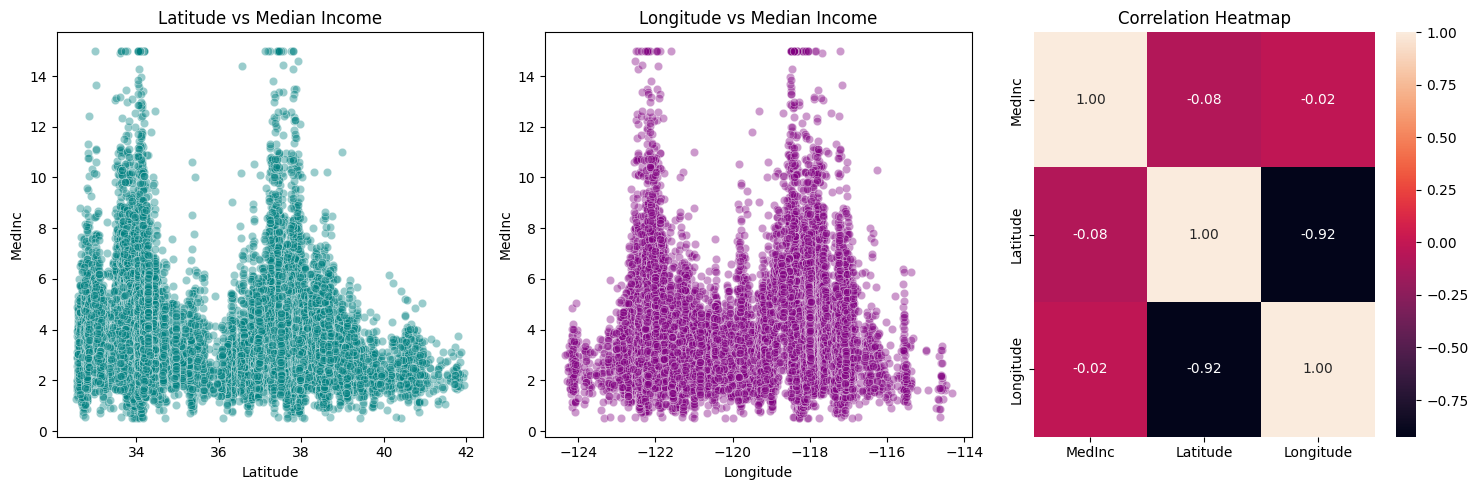

In [52]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x=df['Latitude'], y=df['MedInc'], alpha=0.4, color="teal")
plt.title('Latitude vs Median Income')

plt.subplot(1, 3, 2)
sns.scatterplot(x=df['Longitude'], y=df['MedInc'], alpha=0.4, color="purple")
plt.title('Longitude vs Median Income')

plt.subplot(1, 3, 3)
sns.heatmap(df[['MedInc','Latitude','Longitude']].corr(), annot=True, fmt=".2f")
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()